In [1]:
import yfinance as yf
import polars as pl 
import matplotlib.pyplot as plt
import numpy as np

In [2]:
iren = yf.download("IREN", start="2022-01-01")
print (iren.head())
print(f"Anzahl Datenpunkte: {len(iren)}")


YF.download() has changed argument auto_adjust default to True


c:\Users\tobia\OneDrive\Desktop\test\.pixi\envs\default\Lib\site-packages\yfinance\scrapers\history.py:172: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
[*********************100%***********************]  1 of 1 completed

Price       Close   High     Low   Open  Volume
Ticker       IREN   IREN    IREN   IREN    IREN
Date                                           
2022-01-03  15.23  16.51  15.160  16.25  156900
2022-01-04  13.46  15.35  13.440  15.23  161100
2022-01-05  12.99  13.90  12.990  13.90  149700
2022-01-06  12.51  13.46  12.000  13.00  165500
2022-01-07  11.99  12.87  11.725  12.57  217600
Anzahl Datenpunkte: 1078


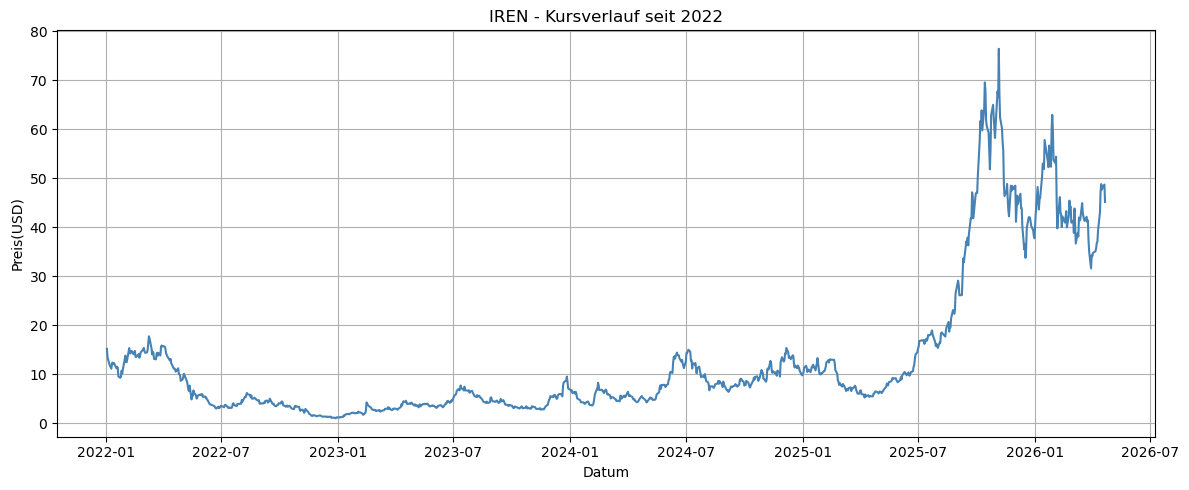

In [3]:
plt.figure(figsize=(12, 5))
plt.plot(iren.index, iren ["Close"], color="steelblue")
plt.title("IREN - Kursverlauf seit 2022")
plt.xlabel("Datum")
plt.ylabel("Preis(USD)")
plt.grid(True)
plt.tight_layout()
plt.show()



In [5]:
iren["Return"] = iren["Close"].pct_change()

print(f"Durchschnittlicher täglicher Return: {iren['Return'].mean().values[0]: .4f}")
print(f"Volatilität(Std): {iren['Return'].std().values[0]:.4f}")
print (f"Bester Tag: {iren['Return'].max().values[0]: .4f}")
print(f"Schlechtester Tag:{ iren['Return'].min().values[0]:.4f}")


AttributeError: 'numpy.float64' object has no attribute 'values'

In [6]:
iren["Return"]= iren ["Close"].pct_change()


print(f"Durchschnittlicher täglicher Return: {iren['Return'].mean():.4f}")
print(f"Volatilität (Std): {iren['Return'].std():.4f}")
print(f"Bester Tag: {iren['Return'].max():.4f}")
print(f"Schlechtester Tag: {iren['Return'].min():.4f}")


Durchschnittlicher täglicher Return: 0.0037
Volatilität (Std): 0.0749
Bester Tag: 0.6699
Schlechtester Tag: -0.3645


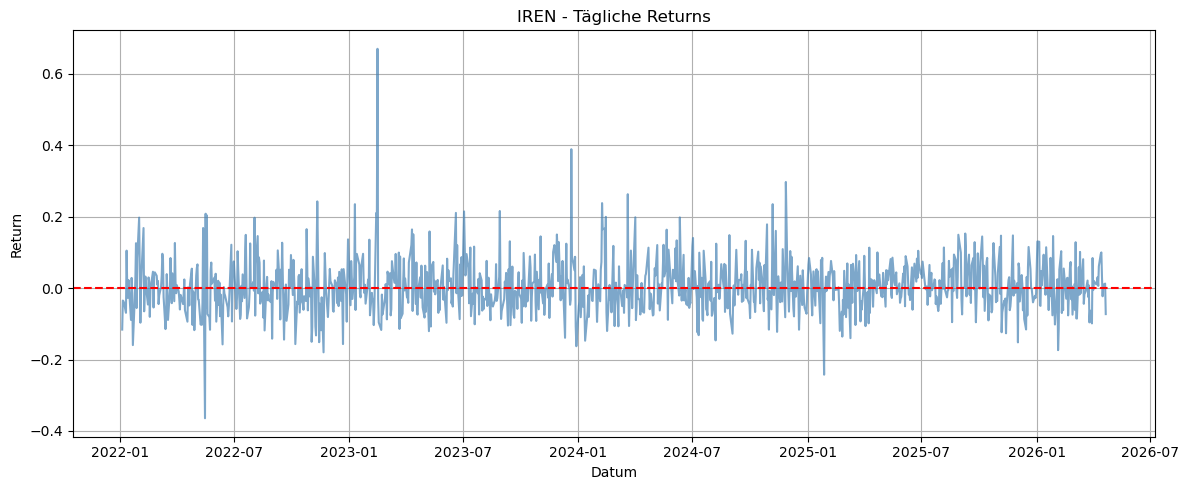

In [7]:
plt.figure(figsize=(12, 5))
plt.plot(iren.index, iren["Return"], color="steelblue", alpha=0.7)
plt.axhline(y=0, color="red", linestyle="--")
plt.title("IREN - Tägliche Returns")
plt.xlabel("Datum")
plt.ylabel("Return")
plt.grid(True)
plt.tight_layout()
plt.show()



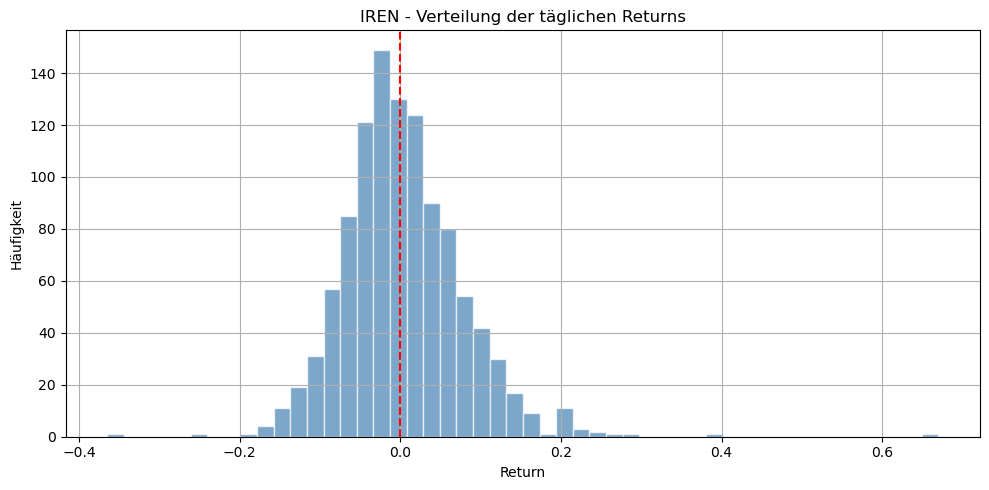

In [8]:
#Histogramm
plt.figure(figsize=(10, 5))
plt.hist(iren["Return"].dropna(), bins=50, color="steelblue", alpha=0.7, edgecolor="white")
plt.axvline(x=0, color="red", linestyle="--")
plt.title("IREN - Verteilung der täglichen Returns")
plt.xlabel("Return")
plt.ylabel("Häufigkeit")
plt.grid(True)
plt.tight_layout()
plt.show()




In [9]:
#Annualisierte Volatilität und sharpe ratio
annual_return = iren["Return"].mean() * 252
annual_volatility = iren["Return"].std() * np.sqrt(252)
sharpe_ratio = annual_return / annual_volatility

print(f"Annualisierter Return: {annual_return:.2%}")
print(f"Annualisierte Volatilität: {annual_volatility:.2%}")
print(f"Sharpe Ratio: {sharpe_ratio:.2f}")

Annualisierter Return: 93.58%
Annualisierte Volatilität: 118.91%
Sharpe Ratio: 0.79


In [10]:
# Bitcoin Daten laden
btc = yf.download("BTC-USD", start="2022-01-01")
print(btc.head())

c:\Users\tobia\OneDrive\Desktop\test\.pixi\envs\default\Lib\site-packages\yfinance\scrapers\history.py:172: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
[*********************100%***********************]  1 of 1 completed

Price              Close          High           Low          Open  \
Ticker           BTC-USD       BTC-USD       BTC-USD       BTC-USD   
Date                                                                 
2022-01-01  47686.812500  47827.312500  46288.484375  46311.746094   
2022-01-02  47345.218750  47881.406250  46856.937500  47680.925781   
2022-01-03  46458.117188  47510.726562  45835.964844  47343.542969   
2022-01-04  45897.574219  47406.546875  45752.464844  46458.851562   
2022-01-05  43569.003906  46929.046875  42798.222656  45899.359375   

Price            Volume  
Ticker          BTC-USD  
Date                     
2022-01-01  24582667004  
2022-01-02  27951569547  
2022-01-03  33071628362  
2022-01-04  42494677905  
2022-01-05  36851084859  


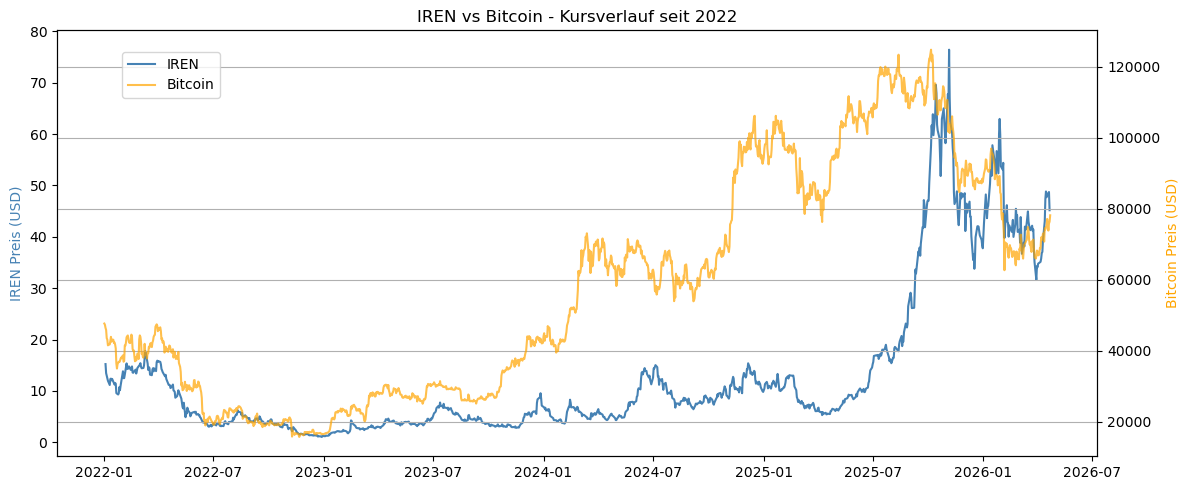

In [11]:
# IREN und Bitcoin Kursverlauf vergleichen
fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.plot(iren.index, iren["Close"], color="steelblue", label="IREN")
ax1.set_ylabel("IREN Preis (USD)", color="steelblue")

ax2 = ax1.twinx()
ax2.plot(btc.index, btc["Close"], color="orange", label="Bitcoin", alpha=0.7)
ax2.set_ylabel("Bitcoin Preis (USD)", color="orange")

plt.title("IREN vs Bitcoin - Kursverlauf seit 2022")
fig.legend(loc="upper left", bbox_to_anchor=(0.1, 0.9))
plt.grid(True)
plt.tight_layout()
plt.show()

In [14]:
# Korrelation zwischen IREN und Bitcoin Returns
iren_returns = iren["Close"].pct_change().dropna().squeeze()
btc_returns = btc["Close"].pct_change().dropna().squeeze()

# Gemeinsamen Zeitraum finden
btc_aligned = btc_returns.reindex(iren_returns.index).dropna()
iren_aligned = iren_returns.reindex(btc_aligned.index)

correlation = iren_aligned.corr(btc_aligned)
print(f"Korrelation IREN vs Bitcoin: {correlation:.4f}")


Korrelation IREN vs Bitcoin: 0.4323


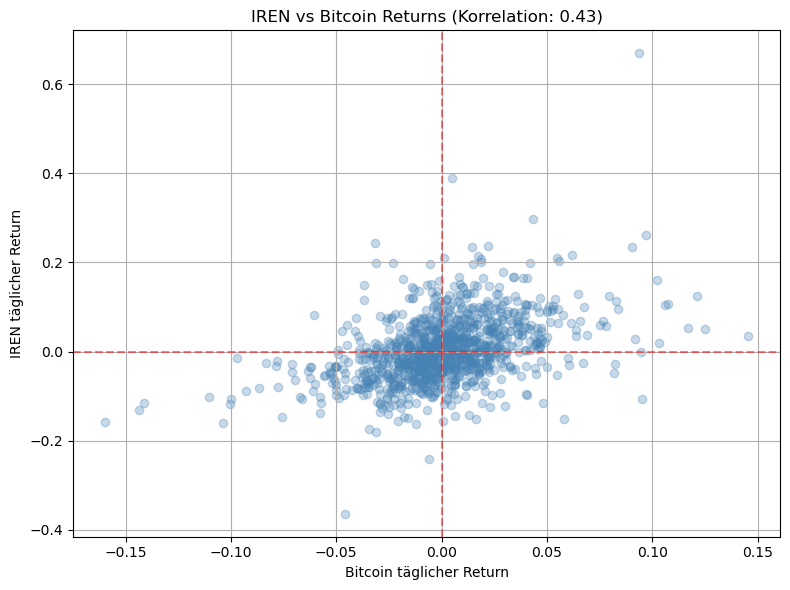

In [15]:
# Scatter Plot IREN vs Bitcoin Returns
plt.figure(figsize=(8, 6))
plt.scatter(btc_aligned, iren_aligned, alpha=0.3, color="steelblue")
plt.xlabel("Bitcoin täglicher Return")
plt.ylabel("IREN täglicher Return")
plt.title(f"IREN vs Bitcoin Returns (Korrelation: {correlation:.2f})")
plt.axhline(y=0, color="red", linestyle="--", alpha=0.5)
plt.axvline(x=0, color="red", linestyle="--", alpha=0.5)
plt.grid(True)
plt.tight_layout()
plt.show()